# Temperature Regression Training
Models: Multiple Linear Regression, Gradient Boosting Regressor, HistGradientBoostingRegressor.  
Target: daily maximum temperature (`temperature_2m_max`).  
Split: 2023–2025 train, 2026 test.


In [1]:
from pathlib import Path
import time, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
ROOT=Path.cwd()
if ROOT.name.lower()!="temperature" and (ROOT/"Temperature").exists(): ROOT=ROOT/"Temperature"
M=ROOT/"trained_models"; M.mkdir(exist_ok=True)
F=["shortwave_radiation_sum","sunshine_duration","daylight_duration","cloud_cover_mean","dew_point_2m_mean","month"]
TARGET="temperature_2m_max"
df=pd.read_csv(ROOT/"dataset"/"temperature_preprocessed.csv"); df["date"]=pd.to_datetime(df["date"])
df=df.dropna(subset=["date"]+F+[TARGET]).sort_values("date")
print("Rows:",len(df)); display(df.head())


Rows: 380685


,prefecture,town,location_id,date,shortwave_radiation_sum,sunshine_duration,daylight_duration,cloud_cover_mean,dew_point_2m_mean,month,temperature_2m_max,temperature_2m_min
0,Aichi,Nagoya,0,2021-01-01,8.04,27176.64,35420.83,49,-2.1,1,5.2,-3.2
131,Osaka,Hirakata,2,2021-01-01,10.05,25648.11,35529.25,23,-4.8,1,3.0,-6.9
132,Osaka,Sakai,3,2021-01-01,10.59,29593.60,35615.25,26,-2.2,1,4.3,1.6
133,Osaka,Kumatori,4,2021-01-01,9.72,26556.68,35658.02,52,-1.8,1,4.1,1.4
134,Saga,Saga,0,2021-01-01,4.19,1733.01,35994.50,92,-1.0,1,6.2,-1.7


In [2]:
train=df[df.date.dt.year.between(2023, 2025)].copy(); test=df[df.date.dt.year==2026].copy()
if train.empty or test.empty: raise ValueError("Need 2021-2025 training and 2026 testing rows.")
train.to_csv(M/"training.csv",index=False); test.to_csv(M/"testing.csv",index=False)
Xtr=train[F]; Xte=test[F]
print("Training:",len(train),"Testing:",len(test))


Training: 224680 Testing: 6355


In [3]:
def models():
    return {
      "Multiple Linear Regression": LinearRegression(),
      "Gradient Boosting": GradientBoostingRegressor(
          n_estimators=200, learning_rate=.05, max_depth=3, random_state=42
      ),
      "HistGradientBoosting": HistGradientBoostingRegressor(
          learning_rate=.1, max_iter=200, max_leaf_nodes=31, random_state=42
      )
    }

filenames = {
    "Multiple Linear Regression": "linear_regression_temp_max.joblib",
    "Gradient Boosting": "gradient_boosting_temp_max.joblib",
    "HistGradientBoosting": "hist_gradient_boosting_temp_max.joblib",
}

rows = []
preds = {}

for name, model in models().items():
    st = time.time()
    model.fit(Xtr, train[TARGET])
    pred = model.predict(Xte)

    mae = mean_absolute_error(test[TARGET], pred)
    rmse = np.sqrt(mean_squared_error(test[TARGET], pred))
    r2 = r2_score(test[TARGET], pred)

    joblib.dump(model, M / filenames[name])

    rows.append({
        "Target": TARGET,
        "Model": name,
        "MAE (°C)": mae,
        "RMSE (°C)": rmse,
        "R²": r2,
        "Training time (s)": time.time() - st
    })
    preds[name] = pred

results = pd.DataFrame(rows)
results.to_csv(M / "model_results.csv", index=False)
display(results.sort_values("RMSE (°C)"))


,Target,Model,MAE (°C),RMSE (°C),R²,Training time (s)
2,temperature_2m_max,HistGradientBoosting,2.104643,2.786099,0.736135,2.845106
1,temperature_2m_max,Gradient Boosting,2.166349,2.858992,0.722148,63.493740
0,temperature_2m_max,Multiple Linear Regression,2.444783,3.152803,0.662105,0.036008


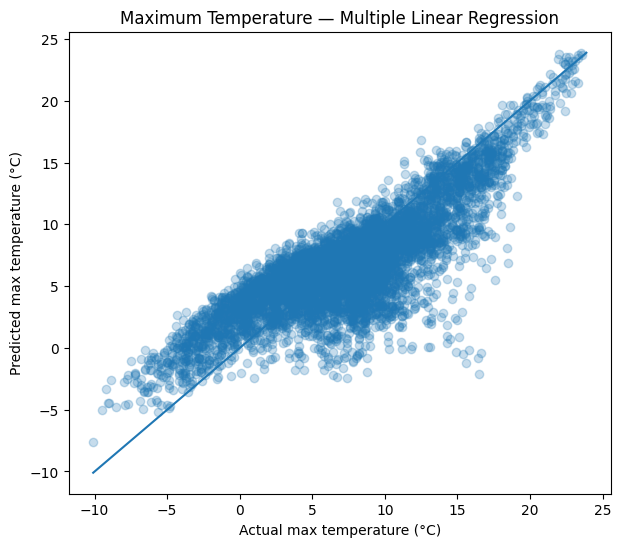

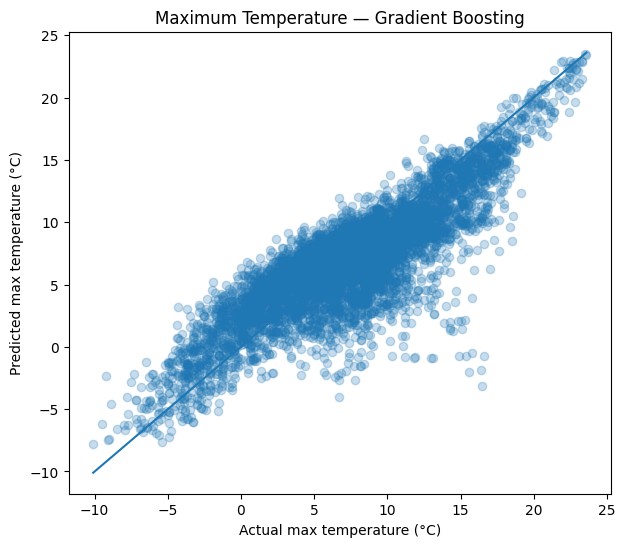

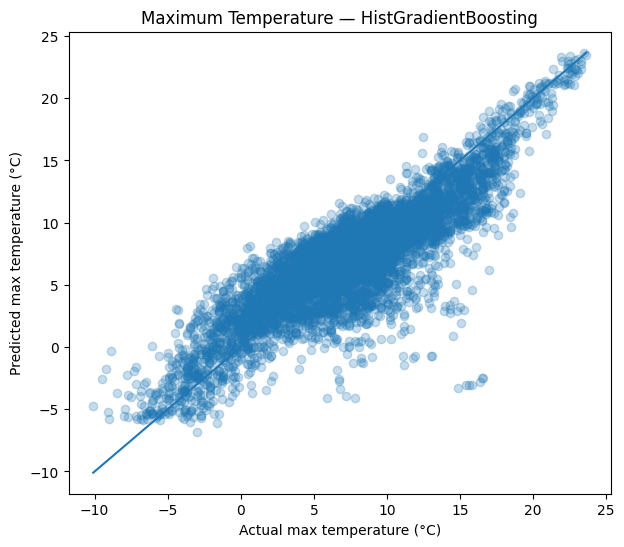

In [4]:
actual = test[TARGET]

for name in ["Multiple Linear Regression", "Gradient Boosting", "HistGradientBoosting"]:
    pred = preds[name]

    plt.figure(figsize=(7, 6))
    plt.scatter(actual, pred, alpha=.25)

    lo = min(actual.min(), pred.min())
    hi = max(actual.max(), pred.max())
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel("Actual max temperature (°C)")
    plt.ylabel("Predicted max temperature (°C)")
    plt.title(f"Maximum Temperature — {name}")
    plt.show()
